This document is focusing on:

1.   data cleaning
2.   data visualization in Power BI


In [ ]:
import pandas as pd

df = pd.read_csv("airbnb_toronto_listings_202607_summary.csv")
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,325432,"Great 'hood, no car needed, 3.5br",1664812.0,1.462564e+18,Mark,NaN,High Park North,43.66106,-79.45605,Entire home/apt,NaN,28,0,NaN,NaN,1.0,0,0,NaN
1,361557,Downtown/Stylish 2 Bdr. Apt /Garden +Parking,174063.0,1.462512e+18,Denis,NaN,South Parkdale,43.63557,-79.43999,Entire home/apt,NaN,750,65,2022-02-05,0.38,4.0,364,0,NaN
2,363057,Charming Century Cottage in Beaches,1816495.0,1.462521e+18,Katharine,NaN,The Beaches,43.67262,-79.30057,Entire home/apt,594.0,28,87,2024-08-25,0.79,1.0,78,0,STR-2203-GGLHHF
3,2042951,Victorian Home On Subway Faces Park,9880504.0,1.462826e+18,Rob,NaN,East End-Danforth,43.69080,-79.29496,Entire home/apt,NaN,180,0,NaN,NaN,2.0,89,0,NaN
4,3139898,Trendy 2 level apt with rooftop deck & free Wi-Fi,15943061.0,1.462974e+18,Carol,NaN,North Riverdale,43.66888,-79.35230,Entire home/apt,498.0,1,13,2026-06-14,0.09,1.0,306,5,STR-2602-HVLLBY


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22256 entries, 0 to 22255
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              22256 non-null  int64  
 1   name                            22256 non-null  object 
 2   host_id                         22212 non-null  float64
 3   host_profile_id                 22211 non-null  float64
 4   host_name                       22211 non-null  object 
 5   neighbourhood_group             0 non-null      float64
 6   neighbourhood                   22256 non-null  object 
 7   latitude                        22256 non-null  float64
 8   longitude                       22256 non-null  float64
 9   room_type                       22256 non-null  object 
 10  price                           17592 non-null  float64
 11  minimum_nights                  22256 non-null  int64  
 12  number_of_reviews               

In [ ]:
# remove irrelevant columns
df_dropped = df.loc[:, df.columns != 'neighbourhood_group']
df_dropped.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,325432,"Great 'hood, no car needed, 3.5br",1664812.0,1.462564e+18,Mark,High Park North,43.66106,-79.45605,Entire home/apt,NaN,28,0,NaN,NaN,1.0,0,0,NaN
1,361557,Downtown/Stylish 2 Bdr. Apt /Garden +Parking,174063.0,1.462512e+18,Denis,South Parkdale,43.63557,-79.43999,Entire home/apt,NaN,750,65,2022-02-05,0.38,4.0,364,0,NaN
2,363057,Charming Century Cottage in Beaches,1816495.0,1.462521e+18,Katharine,The Beaches,43.67262,-79.30057,Entire home/apt,594.0,28,87,2024-08-25,0.79,1.0,78,0,STR-2203-GGLHHF
3,2042951,Victorian Home On Subway Faces Park,9880504.0,1.462826e+18,Rob,East End-Danforth,43.69080,-79.29496,Entire home/apt,NaN,180,0,NaN,NaN,2.0,89,0,NaN
4,3139898,Trendy 2 level apt with rooftop deck & free Wi-Fi,15943061.0,1.462974e+18,Carol,North Riverdale,43.66888,-79.35230,Entire home/apt,498.0,1,13,2026-06-14,0.09,1.0,306,5,STR-2602-HVLLBY


In [ ]:
# check for missing values
missing_percent = round(df_dropped.isnull().sum() / len(df_dropped) * 100, 2)
missing_percent.rename("percentage_of_missing_values (%)")

,percentage_of_missing_values (%)
id,0.00
name,0.00
host_id,0.20
host_profile_id,0.20
host_name,0.20
neighbourhood,0.00
latitude,0.00
longitude,0.00
room_type,0.00
price,20.96


In [ ]:
# add license_numeric column: licensed = 1, not licensed = 0
# and drop the 'license' column
df_dropped['license_num'] = (df_dropped['license'].notna()).astype(int)
df_dropped[['license','license_num']]

df_dropped2 = df_dropped.loc[:, df_dropped.columns != 'license']
df_dropped2.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license_num
0,325432,"Great 'hood, no car needed, 3.5br",1664812.0,1.462564e+18,Mark,High Park North,43.66106,-79.45605,Entire home/apt,NaN,28,0,NaN,NaN,1.0,0,0,0
1,361557,Downtown/Stylish 2 Bdr. Apt /Garden +Parking,174063.0,1.462512e+18,Denis,South Parkdale,43.63557,-79.43999,Entire home/apt,NaN,750,65,2022-02-05,0.38,4.0,364,0,0
2,363057,Charming Century Cottage in Beaches,1816495.0,1.462521e+18,Katharine,The Beaches,43.67262,-79.30057,Entire home/apt,594.0,28,87,2024-08-25,0.79,1.0,78,0,1
3,2042951,Victorian Home On Subway Faces Park,9880504.0,1.462826e+18,Rob,East End-Danforth,43.69080,-79.29496,Entire home/apt,NaN,180,0,NaN,NaN,2.0,89,0,0
4,3139898,Trendy 2 level apt with rooftop deck & free Wi-Fi,15943061.0,1.462974e+18,Carol,North Riverdale,43.66888,-79.35230,Entire home/apt,498.0,1,13,2026-06-14,0.09,1.0,306,5,1


In [ ]:
# check duplicates
df_dropped2.duplicated(subset=['id']).sum()

np.int64(0)

In [ ]:
# investigate missing values in host_id and host_profile_id columns
# RESULT: failed to fill the missing values in host_id column
df_dropped2[df_dropped2['host_id'].isna() & df_dropped2['host_profile_id'].notna()]

,id,name,host_id,host_profile_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license_num


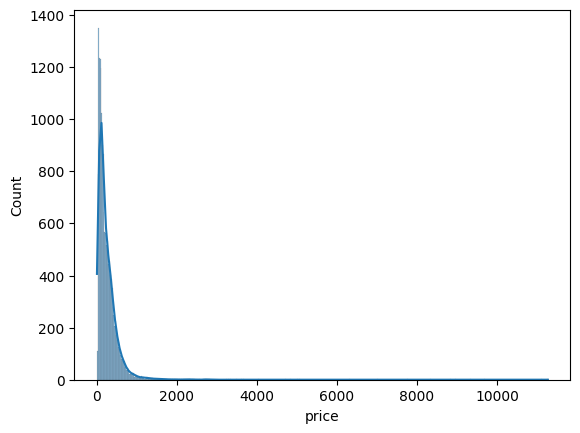

In [ ]:
# clean price column (20.96% missing rate)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df_dropped2, x='price', kde=True)
plt.show()

In [ ]:
# Group by relevant categories and fill with the group median
df_dropped2['price'] = df_dropped2['price'].fillna(
    df_dropped2.groupby(['room_type', 'neighbourhood'])['price'].transform('median')
)

df_dropped2['price']


/tmp/ipykernel_1462/3581046393.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropped2['price'] = df_dropped2['price'].fillna(


,price
0,207.0
1,232.0
2,594.0
3,152.0
4,498.0
...,...
22251,216.0
22252,61.0
22253,136.0
22254,1266.0


In [ ]:
# Fallback to global median if an entire subgroup has only NaNs
df_dropped2['price'] = df_dropped2['price'].fillna(df_dropped2['price'].median())
df_dropped2['price'].isna().sum()


/tmp/ipykernel_1462/1006999738.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropped2['price'] = df_dropped2['price'].fillna(df_dropped2['price'].median())


np.int64(0)

In [ ]:
cols_to_fill = ['reviews_per_month', 'calculated_host_listings_count']
df_dropped2[cols_to_fill] = df_dropped2[cols_to_fill].fillna(0)

df_dropped2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22256 entries, 0 to 22255
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              22256 non-null  int64  
 1   name                            22256 non-null  object 
 2   host_id                         22212 non-null  float64
 3   host_profile_id                 22211 non-null  float64
 4   host_name                       22211 non-null  object 
 5   neighbourhood                   22256 non-null  object 
 6   latitude                        22256 non-null  float64
 7   longitude                       22256 non-null  float64
 8   room_type                       22256 non-null  object 
 9   price                           22256 non-null  float64
 10  minimum_nights                  22256 non-null  int64  
 11  number_of_reviews               22256 non-null  int64  
 12  last_review                     

/tmp/ipykernel_1462/2275526156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropped2[cols_to_fill] = df_dropped2[cols_to_fill].fillna(0)


In [ ]:
df_dropped2['last_review'] = pd.to_datetime(df_dropped2['last_review'])
df_dropped2['last_review']

/tmp/ipykernel_1462/3719190312.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropped2['last_review'] = pd.to_datetime(df_dropped2['last_review'])


,last_review
0,NaT
1,2022-02-05
2,2024-08-25
3,NaT
4,2026-06-14
...,...
22251,NaT
22252,NaT
22253,NaT
22254,NaT


In [ ]:
df_dropped2['room_type'].value_counts()

,count
room_type,
Entire home/apt,15169
Private room,7005
Hotel room,58
Shared room,24


In [ ]:
# export cleaned data to .csv
df_dropped2.to_csv('cleaned_airbnb_toronto_listings_202607_summary.csv', index=True)